## Preamble

### Description

This dataset is called "Gen AI Misinformation Detection Data (2024–2025)." It is a tabular dataset containing information on recent news articles and social media posts, with each post labeled as being either AI-generated misinformation or not [1]. We will perform exploratory data analysis to visualize the dataset and prepare the dataset for learning. Then, we will train two models, a Naive Bayes classifer and a _K_-Nearest Neighbors classifier. We conclude with a discussion of the results.

### Imports

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sps
from IPython.display import display, Latex, Markdown

from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from mixed_naive_bayes import MixedNB

## Exploratory Data Analysis

We begin by loading the dataset:

In [176]:
df = pd.read_csv('generative_ai_misinformation_dataset.csv')

Let's see how many samples and how many features there are:

In [177]:
df.shape

(500, 31)

It appears there are 500 rows and 30 features (not 31 because 1 column represents the label).

Let's take a brief look at the dataset:

In [178]:
df.head()

,id,post_id,platform,timestamp,date,time,month,weekday,country,city,...,sentiment_score,toxicity_score,model_signature,detected_synthetic_score,embedding_sim_to_facts,factcheck_verdict,external_factchecks_count,source_domain_reliability,engagement,is_misinformation
0,1,P0001,Reddit,2024-03-06 10:01:00,2024-03-06,10:01:00,March,Wednesday,USA,New York,...,-0.223,0.271,GPT-like,0.829,0.357,TRUE,4,0.543,3899,1
1,2,P0002,Reddit,2025-08-07 18:30:00,2025-08-07,18:30:00,August,Thursday,Germany,Berlin,...,-0.718,0.802,GPT-like,0.075,0.987,FALSE,3,0.199,7651,0
2,3,P0003,Telegram,2024-12-13 03:15:00,2024-12-13,03:15:00,December,Friday,USA,New York,...,-0.989,0.815,GPT-like,0.707,0.729,PARTLY,0,0.074,7260,0
3,4,P0004,Twitter,2024-04-05 07:10:00,2024-04-05,07:10:00,April,Friday,USA,Chicago,...,-0.283,0.116,human,0.863,0.623,FALSE,2,0.064,7454,1
4,5,P0005,Telegram,2024-06-07 06:18:00,2024-06-07,06:18:00,June,Friday,Germany,Hamburg,...,-0.378,0.325,GPT-like,0.730,0.638,PARTLY,0,0.472,8320,0


There are 500 samples with 30 columns and 1 target label ```is_misinformation```. Some columns are not really features, for example the two ID columns. The timestamp of the post is included, and so are some derived columns like ```date```, ```time```, ```month```, and ```weekday```. There are columms containing information about the post author and a substantial number of columns related to the post content.

There are some raw features like ```text_length```, ```num_urls```, etc. However, there are also a fair few processed features such as ```readability_score```, ```sentiment_score```, etc. This reduces our need to perform significant feature engineering.

It would be beneficial if the ```text``` column actually contained the text of the post. However, it contains only dummy text.

Variables:
- Numerical variables: ```author_followers```, ```text_length```, ```token_count```, ```readability_score```, ```num_urls```, ```num_mentions```, ```num_hashtags```, ```sentiment_score```, ```toxicity_score```, ```detected_synthetic_score```, ```embedding_sim_to_facts```, ```external_factchecks_count```, ```source_domain_reliability```, ```engagement```

- Categorical variables: ```platform```, ```month```, ```weekday```, ```country```, ```city```, ```timezone```, ```author_verified```, ```model_signature```, ```factcheck_verdict```, ```is_misinformation```

- Other variables: ```id```, ```post_id```, ```timestamp```, ```date```, ```time```, ```author_id```, ```text```

Let's analyze the balance of the classes:

In [179]:
df['is_misinformation'].value_counts()

is_misinformation
1    268
0    232
Name: count, dtype: int64

Out of 500 samples, close to half belong to each class. This is a fairly balanced datset.

Let's inspect to see if there are missing values we need to handle:

In [180]:
df.isna().sum().rename('Missing Value Count')

id                           0
post_id                      0
platform                     0
timestamp                    0
date                         0
time                         0
month                        0
weekday                      0
country                      0
city                         0
timezone                     0
author_id                    0
author_followers             0
author_verified              0
text                         0
text_length                  0
token_count                  0
readability_score            0
num_urls                     0
num_mentions                 0
num_hashtags                 0
sentiment_score              0
toxicity_score               0
model_signature              0
detected_synthetic_score     0
embedding_sim_to_facts       0
factcheck_verdict            0
external_factchecks_count    0
source_domain_reliability    0
engagement                   0
is_misinformation            0
Name: Missing Value Count, dtype: int64

It looks like this dataset is free of missing values. Futhermore, there is no evidence to suggest, in either the dataset's online source or the dataset itself, that missing values are hidden in the guise of dummy values like -1 or infinity. A closer look at the online source reveals that the dataset is actually obtained from simulations.

We want to analyze the distribution of individual features. It would be helpful if the distributions were Gaussian because then Gaussian Naive Bayes could be used. Note we are looking only at numerical features:

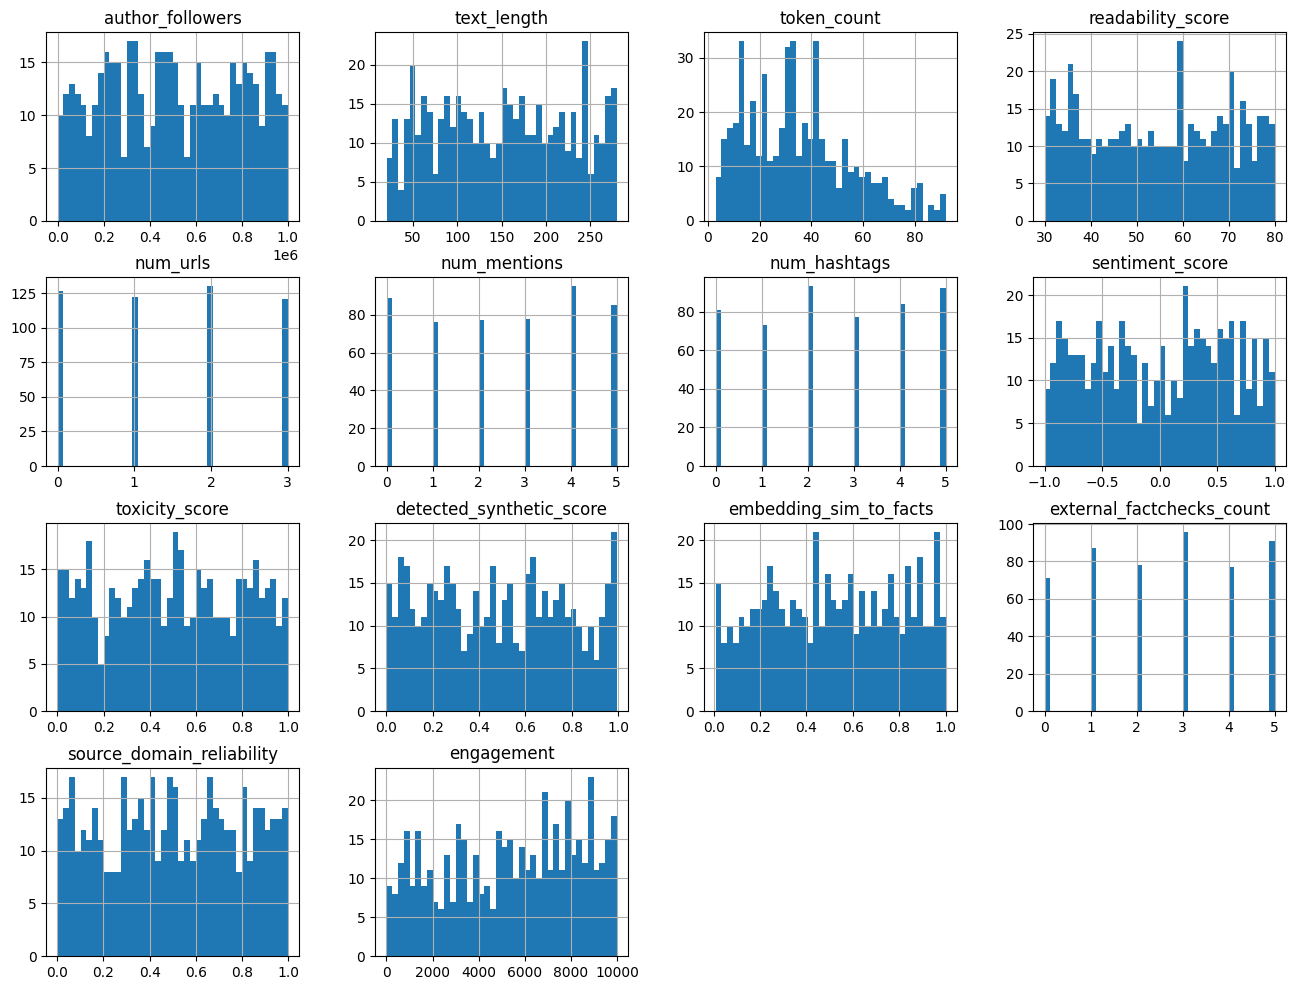

In [181]:
numeric_cols = ['author_followers', 'text_length', 'token_count', 'readability_score', 'num_urls', 'num_mentions', 'num_hashtags', 'sentiment_score', 'toxicity_score', 'detected_synthetic_score', 'embedding_sim_to_facts', 'external_factchecks_count', 'source_domain_reliability', 'engagement']
_ = df[numeric_cols].hist(figsize = (16, 12), bins = 40)

It seems like most of the features don't quite exhibit the bell shape of a Gaussian distribution. Instead, these histograms are a bit more flat.

## Feature Extraction

Notice that we have a ```timestamp``` column which holds a datetime object. This isn't particularly useable for machine learning. Let's derive features that might be useful for misinformation detection, such as ```year```, ```day_of_month```, and ```hour```. Notice ```month``` already exists in the original dataset:

In [182]:
df_processed = df.copy()
df_processed['timestamp'] = pd.to_datetime(df['timestamp'])
df_processed['year'] = df_processed['timestamp'].dt.year            # Get year from timestamp
df_processed['day_of_month'] = df_processed['timestamp'].dt.day     # Get day of month from timestamp
df_processed['hour'] = df_processed['timestamp'].dt.hour            # Get hour from timestamp

numeric_cols += ['year', 'day_of_month', 'hour']
df_processed[['year', 'day_of_month', 'hour']].head()               # Display output

,year,day_of_month,hour
0,2024,6,10
1,2025,7,18
2,2024,13,3
3,2024,5,7
4,2024,7,6


As mentioned before, many of the features present in the dataset are already processed rather than being raw features. Thus, it should be sufficient to use the features provided without too much more feature engineering.

## Pre-processing

We begin by removing some irrelevant features that have no predictive value:

In [183]:
df_processed = df_processed.drop(['id', 'post_id', 'timestamp', 'date', 'time', 'author_id', 'text'], axis = 1)

Now, we need to encode categorical features into numerical values. Let's start by one-hot encoding the nominal features:

In [184]:
nominal_cols = ['platform', 'month', 'weekday', 'country', 'city', 'timezone', 'model_signature']   # nominal features
df_processed = pd.get_dummies(df_processed, columns = nominal_cols, dtype = np.int64)               # pd.get_dummies performs one-hot encoding
df_processed.head()

,author_followers,author_verified,text_length,token_count,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,...,city_Rio de Janeiro,city_Sao Paulo,timezone_BRT,timezone_CET,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown
0,74491,0,137,34,44.05,1,0,0,-0.223,0.271,...,0,0,0,0,1,0,0,1,0,0
1,199709,0,144,24,68.61,0,5,3,-0.718,0.802,...,0,0,0,1,0,0,0,1,0,0
2,470455,0,118,29,68.56,3,1,2,-0.989,0.815,...,0,0,0,0,1,0,0,1,0,0
3,224180,1,228,38,46.54,0,1,3,-0.283,0.116,...,0,0,0,0,1,0,0,0,1,0
4,63968,1,131,43,74.36,0,0,4,-0.378,0.325,...,0,0,0,1,0,0,0,1,0,0


Next, we look at ordinal data. There appears to be only 1 ordinal feature, ```factcheck_verdit```, whose values are given below:

In [185]:
df_processed['factcheck_verdict'].unique()

array(['TRUE', 'FALSE', 'PARTLY', 'UNVERIFIED'], dtype=object)

This is ordinal because 'TRUE' is better than 'PARTLY' which is better than 'FALSE'. 'UNVERIFIED' can be seen as its own type, so we can put it below 'FALSE':

In [186]:
df_processed['factcheck_verdict'] = df_processed['factcheck_verdict'].apply(lambda verdict:                     # Label-encode factcheck_verdit
                                                                                3 if verdict == 'TRUE' else 
                                                                                2 if verdict == 'PARTLY' else 
                                                                                1 if verdict == 'FALSE'
                                                                                else 0                          # 0 for 'UNVERIFIED'
                                                                            )

Next, we'll turn our attention to analyzing the correlation between pairs of features:

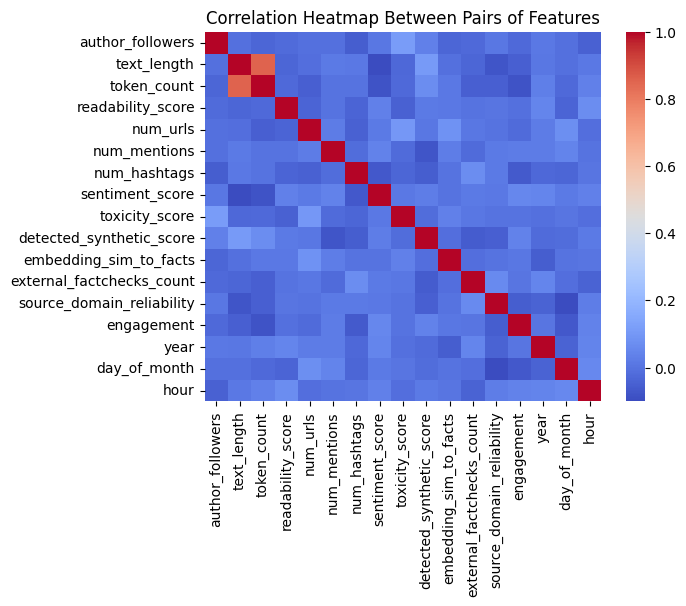

In [187]:
sns.heatmap(df_processed[numeric_cols].corr(), cmap = 'coolwarm')   # Maybe don't restrict to numerical cols
_ = plt.title('Correlation Heatmap Between Pairs of Features')

It is clear that we can remove ```token_count``` because it correlates highly with ```text_length```, which makes sense.

In [188]:
df_processed = df_processed.drop('token_count', axis = 1)   # Remove token_count
numeric_cols.remove('token_count')

Finally, we can take a look at our final processed dataset ready for machine learning tasks.

In [189]:
df_processed.head()

,author_followers,author_verified,text_length,readability_score,num_urls,num_mentions,num_hashtags,sentiment_score,toxicity_score,detected_synthetic_score,...,city_Rio de Janeiro,city_Sao Paulo,timezone_BRT,timezone_CET,timezone_EST,timezone_GMT,timezone_IST,model_signature_GPT-like,model_signature_human,model_signature_unknown
0,74491,0,137,44.05,1,0,0,-0.223,0.271,0.829,...,0,0,0,0,1,0,0,1,0,0
1,199709,0,144,68.61,0,5,3,-0.718,0.802,0.075,...,0,0,0,1,0,0,0,1,0,0
2,470455,0,118,68.56,3,1,2,-0.989,0.815,0.707,...,0,0,0,0,1,0,0,1,0,0
3,224180,1,228,46.54,0,1,3,-0.283,0.116,0.863,...,0,0,0,0,1,0,0,0,1,0
4,63968,1,131,74.36,0,0,4,-0.378,0.325,0.730,...,0,0,0,1,0,0,0,1,0,0


## Model Selection

Let's create a scatterplot of the data by projecting the features onto the 2 most explaining dimensions provided by PCA. This will help with model selection:

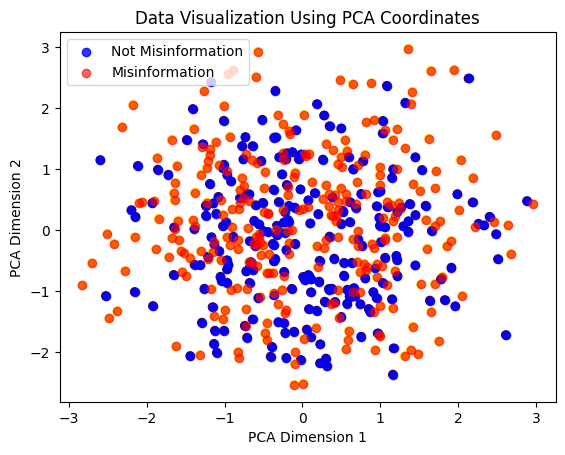

In [198]:
X = df_processed[numeric_cols].copy()                             # features to perform PCA on
y = df_processed['is_misinformation'].copy()                      # labels used for coloring

scaler = StandardScaler()
X = scaler.fit_transform(X)

pca = PCA(n_components = 10)
X_pca = pca.fit_transform(X)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y)

X0 = X_pca[y == 0]
X1 = X_pca[y == 1]
plt.scatter(X0[:, 0], X0[:, 1], c = 'blue', alpha = 0.8, label = 'Not Misinformation')
plt.scatter(X1[:, 0], X1[:, 1], c = 'red', alpha = 0.6, label = 'Misinformation')

plt.title('Data Visualization Using PCA Coordinates')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.legend()

This data does not seem particularly suitable for finding a general decision boundary. Certainly, methods such as LDA, QDA, and SVC with linear kernel are not appropriate as there does not appear to be a linear or quadratic decision boundary, nor is there any evidence to suggest the features follow a Gaussian distribution. We can attempt to use Naive Bayes and K-Nearest Neighbors, though we should not expect very good results considering the above plot.

## Model 1: Naive Bayes Classifier

Naive Bayes is a simple classifier that makes the strong assumption that features become independent when conditioned on the classes.

As seen in exploratory data analysis, our dataset contains a mix of numerical and categorical variables. A continuous PDF is suitable for approximating the numerical features, while a multinomial distribution works well for categorical features. Thus, we take the approach of a mixed Naive Bayes classifier where each feature's likelihood function can be either Gaussian or multinomial depending on its data type.

It is highly desired to have the numerical features exhibit Gaussian likelihoods. While this is not the case, as seen earlier, we can use the Quantile transformation to make these features Gaussian [2]. Below is a demonstration (only for visualization purposes; the dataset was not modified in this step):

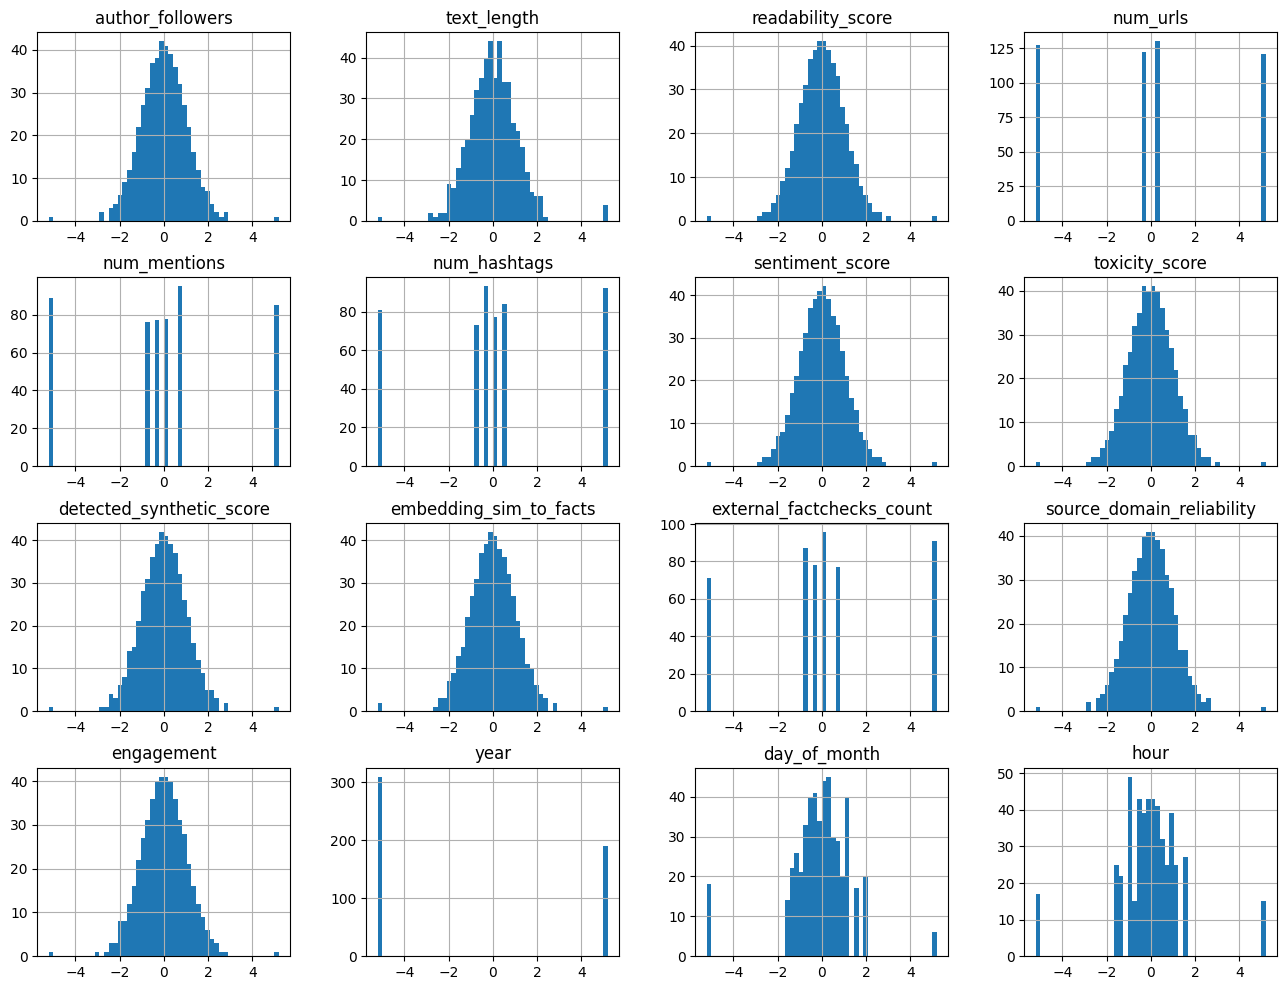

In [191]:
qtransformer = QuantileTransformer(output_distribution = 'normal', n_quantiles = 400)
df_dummy = df_processed[numeric_cols].copy()
df_dummy[:] = qtransformer.fit_transform(df_dummy)
_ = df_dummy.hist(figsize=(16, 12), bins = 50)

Now, the features follow a Gaussian distribution.

Below, we implment a mixed Naive Bayes classifier. We begin with defining the classifier, then we perform K-fold cross validation with $K = 5$. Importantly, we fit the quantile transformation using the training set corresponding to each fold to avoid data leakage [3].

In [192]:
X = df_processed.drop('is_misinformation', axis = 1)        # features
y = df_processed['is_misinformation']                       # labels

categ_cols = [i for i in range(X.shape[1]) if X.columns[i] not in numeric_cols]
mnb = MixedNB(categorical_features = categ_cols)            # classifier which takes in a list of categorical columns and automatically computes the likelihoods for each feature

mnb_accuracies = []
mnb_preds = np.zeros_like(y)
mnb_probs = np.zeros_like(y)

cv = KFold(n_splits = 5, shuffle = True, random_state = 42) # K-fold cross validation for evaluating the model
for train, test in cv.split(X):
    X_train, X_test, y_train, y_test = X.iloc[train].copy(), X.iloc[test].copy(), y.iloc[train].copy(), y.iloc[test].copy() # Obtain training and testing data for each fold

    X_train[numeric_cols] = qtransformer.fit_transform(X_train[numeric_cols])   # Fit and apply quantile transformation to training data
    X_test[numeric_cols] = qtransformer.transform(X_test[numeric_cols])         # Apply quantile transformation to test data

    mnb.fit(X_train, y_train)                                                   # Train model using training data
    mnb_accuracies.append(mnb.score(X_test, y_test))                            # Accuracy from predicting on test data
    mnb_preds[test] = mnb.predict(X_test)                                       # Actual predictions from test data
    mnb_probs[test] = mnb.predict_proba(X_test)[:, 1]                           # Probability of being misclassification

    print(f'Fold:')
    # print(f'\tPrediction: {mnb_preds[test]}')
    print(f'\tTraining accuracy: {mnb.score(X_train, y_train)}')
    print(f'\tTesting accuracy: {mnb_accuracies[-1]}')

print(f'\nAccuracy: {np.mean(mnb_accuracies)}')

Fold:
	Training accuracy: 0.645
	Testing accuracy: 0.47
Fold:
	Training accuracy: 0.615
	Testing accuracy: 0.47
Fold:
	Training accuracy: 0.645
	Testing accuracy: 0.45
Fold:
	Training accuracy: 0.6325
	Testing accuracy: 0.44
Fold:
	Training accuracy: 0.6225
	Testing accuracy: 0.49

Accuracy: 0.46399999999999997


c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':
c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:423: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if categorical_features == 'all':
c:\Users\Rohit\.venv\Lib\site-packages\mixed_naive_bayes\mixed_naive_bayes.py:163: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  elif self.categorical_features == 'all':
c:\Use

We can see the results over the 5 validation folds. The training accuracy is around 60% and the testing is around 50%. There does not appear to be overfitting as the training accuracy is not very high.

## Model 2: _K_-Nearest Neighbors (KNN)

KNN is a classifier that uses the entire training sample to make a prediction on a test sample using the nearest neighbors of the test sample. Below, we have implemented KNN. We use _K_-fold cross validation to evaluate the model. We also use a cross-validation scheme for tuning the hyperparamters ```n_neighbors``` and the ```metric``` for distance [4]. This hyperparameter tuning occurs inside each fold of the _K_-fold evaluation process. We perform standardization, as required by the KNN algorithm, using the training data for each fold to fit the standardizer.

In [193]:
X = df_processed.drop('is_misinformation', axis = 1).copy()     # features
y = df_processed['is_misinformation'].copy()                    # labels

knn = KNeighborsClassifier(
    weights = 'uniform',
    algorithm = 'auto'
)

params = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25], 'metric': ['l1', 'chebyshev']}    # parameter grid to find best values for K and distance metric
clf = GridSearchCV(                                                                                         # GridSearchCV performs cross-validation to select the best hypeparameters
    estimator = knn,
    param_grid = params,
    scoring = 'accuracy',
    cv = 5,
    verbose = 1
)

knn_accuracies = []
knn_preds = np.zeros_like(y)
knn_probs = np.zeros_like(y)

cv = KFold(n_splits = 5, shuffle = True, random_state = 42) # K-fold cross validation for evaluating the model
for train, test in cv.split(X):
    X_train, X_test, y_train, y_test = X.iloc[train].copy(), X.iloc[test].copy(), y.iloc[train].copy(), y.iloc[test].copy() # Obtain training and testing data for each fold

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)                             # Fit and apply standardization to training data
    X_test = scaler.transform(X_test)                                   # Apply standardization to test data

    clf.fit(X_train, y_train)                                           # Train model using training data                                        
    knn_accuracies.append(clf.score(X_test, y_test))                    # Accuracy from predicting on test data
    knn_preds[test] = clf.predict(X_test)                               # Actual predictions from test data
    mnb_probs[test] = clf.predict_proba(X_test)[:, 1]                   # Probability of being misclassification

    print(f'Fold:')
    # print(f'\tPrediction: {knn_preds[test]}')
    print(f'\tTraining accuracy: {clf.score(X_train, y_train)}')
    print(f'\tTesting accuracy: {knn_accuracies[-1]}')
    print(f'\tBest params: {clf.best_params_}')

print(f'\nAccuracy: {np.mean(knn_accuracies)}')

Fitting 5 folds for each of 26 candidates, totalling 130 fits
Fold:
	Training accuracy: 1.0
	Testing accuracy: 0.52
	Best params: {'metric': 'l1', 'n_neighbors': 1}
Fitting 5 folds for each of 26 candidates, totalling 130 fits
Fold:
	Training accuracy: 1.0
	Testing accuracy: 0.52
	Best params: {'metric': 'l1', 'n_neighbors': 1}
Fitting 5 folds for each of 26 candidates, totalling 130 fits
Fold:
	Training accuracy: 0.77
	Testing accuracy: 0.48
	Best params: {'metric': 'chebyshev', 'n_neighbors': 3}
Fitting 5 folds for each of 26 candidates, totalling 130 fits
Fold:
	Training accuracy: 0.6575
	Testing accuracy: 0.51
	Best params: {'metric': 'chebyshev', 'n_neighbors': 9}
Fitting 5 folds for each of 26 candidates, totalling 130 fits
Fold:
	Training accuracy: 1.0
	Testing accuracy: 0.51
	Best params: {'metric': 'l1', 'n_neighbors': 1}

Accuracy: 0.508


## (Ignore) Model 3: Support Vector Machine (SVM)

In [199]:
# X = df_processed.drop('is_misinformation', axis = 1).copy()
# y = df_processed['is_misinformation'].copy()

# svm = SVC(
#     shrinking = False,
#     probability = True,
#     tol = 1e-3,
#     cache_size = 200,
#     class_weight = None,
#     max_iter = -1,
#     verbose = True
# )

# # pipeline = Pipeline(steps = [('standardization', StandardScaler()), ('svm', svm)])

# params = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'kernel': ['rbf'], 'gamma': [1000, 100, 10, 1, 0.1, 0.01, 0.001, 0.0001, 1e-5, 1e-6, 1e-7]}
# clf = GridSearchCV(
#     estimator = svm,
#     param_grid = params,
#     scoring = 'accuracy',
#     cv = 5,
#     verbose = 1
# )

# svm_accuracies = []
# svm_preds = np.zeros_like(y)
# svm_probs = np.zeros_like(y)

# cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
# for train, test in cv.split(X):
#     X_train, X_test, y_train, y_test = X.iloc[train].copy(), X.iloc[test].copy(), y.iloc[train].copy(), y.iloc[test].copy()

#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     clf.fit(X_train, y_train)
#     svm_accuracies.append(clf.score(X_test, y_test))
#     svm_preds[test] = clf.predict(X_test)
#     svm_probs[test] = clf.predict_proba(X_test)[:, 1]

#     print(f'Fold:')
#     print(f'\tPrediction: {svm_preds[test]}')
#     print(f'\tTraining accuracy: {clf.score(X_train, y_train)}')
#     print(f'\tTesting accuracy: {svm_accuracies[-1]}')
#     print(f'\tBest params: {clf.best_params_}')

# print(f'Accuracy: {np.mean(svm_accuracies)}')

# # scores = cross_val_score(
# #     estimator = clf,
# #     X = X, 
# #     y = y,
# #     scoring = 'accuracy',
# #     cv = 5,
# #     # n_jobs = -1,
# # )
# # print(f'\nAccuracy: {scores.mean()}')

## Comparative Analysis

As a high level overview, let's redisplay the accuracies of Naive Bayes and KNN resulting from K-fold cross validation:

In [195]:
print(f'Naive Bayes Accuracy: {np.mean(mnb_accuracies)}')
print(f'KNN Accuracy: {np.mean(knn_accuracies)}')

Naive Bayes Accuracy: 0.46399999999999997
KNN Accuracy: 0.508


These are about the same, although accuracy is slighly higher for KNN.

Let's take a look at the confusion matrices for the Naive Bayes and KNN classifiers:

Text(0.5, 1.0, 'Confusion Matrix (KNN)')

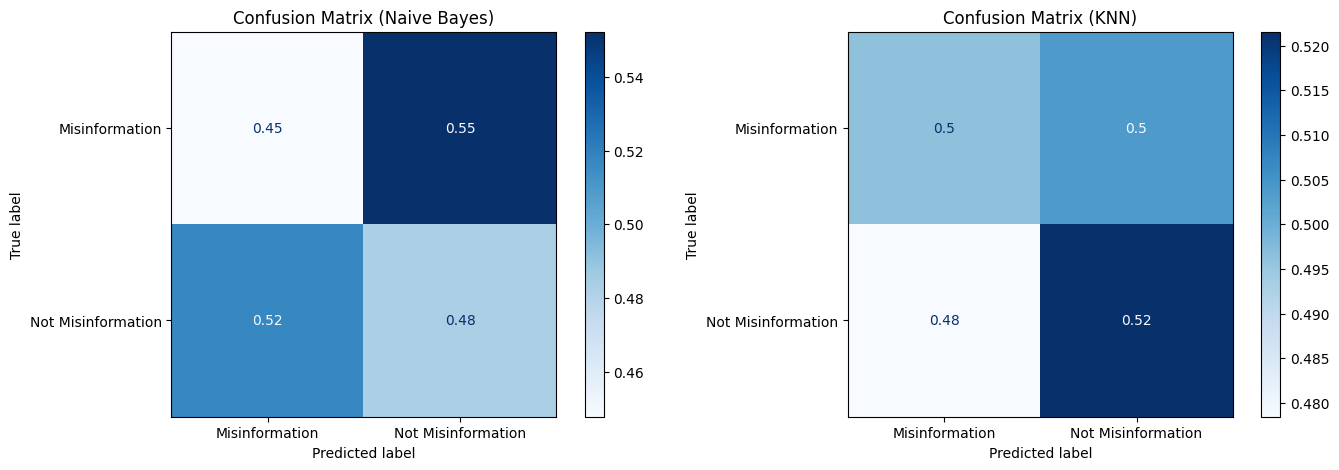

In [196]:
labels = ['Not Misinformation', 'Misinformation']
y_labels = list(map(lambda z: labels[z], y))
mnb_preds_labels = list(map(lambda z: labels[z], mnb_preds))
knn_preds_labels = list(map(lambda z: labels[z], knn_preds))

fig, axs = plt.subplots(1, 2, figsize = (16, 5))
ConfusionMatrixDisplay.from_predictions(y_labels, mnb_preds_labels, normalize = 'true', cmap = 'Blues', ax = axs[0])
ConfusionMatrixDisplay.from_predictions(y_labels, knn_preds_labels, normalize = 'true', cmap = 'Blues', ax = axs[1])
axs[0].set_title('Confusion Matrix (Naive Bayes)')
axs[1].set_title('Confusion Matrix (KNN)')

Again, very even performance across both models.

Let's try looking at the Reciever Operating Curve (ROC):

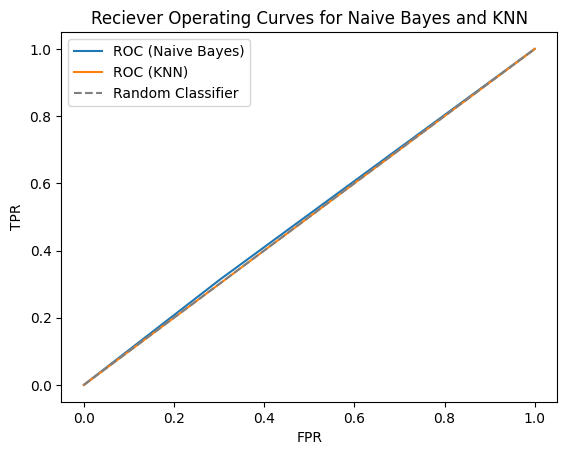

Naive Bayes Area Under Curve (AUC): 0.5058543489449305
KNN Area Under Curve (AUC): 0.5


In [197]:
mnb_fpr, mnb_tpr, _ = roc_curve(y, mnb_probs)
knn_fpr, knn_tpr, _ = roc_curve(y, knn_probs)

plt.plot(mnb_fpr, mnb_tpr, label = 'ROC (Naive Bayes)')
plt.plot(knn_fpr, knn_tpr, label = 'ROC (KNN)')
plt.plot([0, 1], [0, 1], '--', color = 'gray', label = 'Random Classifier')
plt.title('Reciever Operating Curves for Naive Bayes and KNN')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

print(f'Naive Bayes Area Under Curve (AUC): {roc_auc_score(y, mnb_probs)}')
print(f'KNN Area Under Curve (AUC): {roc_auc_score(y, knn_probs)}')

Overall, there is not much difference between the Naive Bayes classifier, the KNN classifier, and a random classifier. As stated previously, this is as expected because the dataset does not exhibit separable characteristics. Even a complex decision boundary provided by KNN does not suffice for this problem.

In terms of which model to pick, we would recommend KNN. KNN has a slightly higher accuracy than Naive Bayes. Furthermore, all the diagonal entries of the confusion matrix for KNN are greater than or equal to 50%, whereas this is true only for the off-diagonal entries for Naive Bayes. We recommend KNN in spite of the fact that KNN possesses a larger computational complexity and memory overhead than the simple Naive Bayes. However, KNN can manage complex decision boundaries, which is more suitable for this problem.

## Ethical Discussion

There are several ethical issues involved in classifying online material as AI-generated misinformation or not. First comes the risk of classifying genuine content as misinformation—human authors will then be penalized despite producing authentic work, and their reputations may suffer needlessly. Of course, there is also the other case: classifying misinformation as real information. This is arguably the worse of the two as the readers of that content will believe in the fake news, contributing to deeper issues such as political divide, circulation of improper medical advice, and economic losses.

Privacy is also a concern. The identity of human authors must be kept anonymous in the dataset. The dataset has, appropriately, already dealt with this by maintaining only post_ids and author_ids that are intraceable to the source. Another concern is that authors should consent to their work being used to train a machine learning model.

Another issue is bias in the dataset, which would propogate into the core of the classifier itself. For example, the dataset might be biased towards suggesting that posts from certain countries are more likely than not to have misinformation. This could lead to more human authors from those countries unfairly being labeled as inauthentic.

## Bibliography

- [1] https://www.kaggle.com/datasets/atharvasoundankar/gen-ai-misinformation-detection-datase-20242025
- [2] https://scikit-learn.org/stable/modules/preprocessing.html#mapping-to-a-gaussian-distribution
- [3] https://machinelearningmastery.com/data-preparation-without-data-leakage/
- [4] https://scikit-learn.org/stable/modules/grid_search.html#exhaustive-grid-search